# Malata mountain + tau-decay geometry


Visual sanity check for the v6 pipeline after switching the mountain to **`malata.h5`**
and the shower primaries to the real tau events in **`tau_wholesky.h5`**.

Both files live in the **same site-local ENU frame** (`x=East, y=North, z=Up`), with the
origin at the mesh's `location` (lon −71.97°, lat −15.58°). `load_tr_mountain` now reads
that origin from the mesh, so the mountain centroids and the tau decay positions share
`(East, North, Up) = 0`.

This notebook plots:
1. the **mountain** detector region (footprint + height),
2. the **tau decays** overlaid on the mountain,
3. the **initial detector layouts** placed over the mountain,
4. a combined **overlay** of all three.


## 0 - Coordinate systems & transformations

Everything shares one physical frame: site-local **ENU** (East, North, Up), right-handed
(E x N = U), metres, origin at the malata mesh `location` (lon -71.969, lat -15.577). What differs
is how each object is stored or parameterised before it lands in that frame.

| Object | Native form | In the ENU frame |
|---|---|---|
| Mountain (`malata.h5`) | ECEF vertices [m] | rotated to ENU; centroids stored as [North, Up, East] |
| Tau decays (`tau_wholesky.h5`) | ENU (East, North, Up) | position + direction, same origin |
| Detectors | (North, East) horizontal | Up = SurfaceUpMap(North, East) on the terrain |
| Showers | shower-local [x, y, layer, E, t] | transverse (x,y) -> (North, Up); layer -> East depth |

**Transformations**
- **ECEF -> ENU** (mountain): rotate the mesh about the site origin (`load_tr_mountain`).
- **Detector (North, East) -> Up**: bilinear terrain lookup, `Up = SurfaceUpMap(North, East)`.
- **Shower placement** (real tau position, Step 1): translate the cloud so its transverse centroid
  lands at the decay's (North, Up), and shift `layer_index` by `(east_entry - East_decay)/layer_dx`
  so the real East sets which detector plane it aligns with. A point's East = `east_entry - layer*layer_dx`.
- All plots below use right-handed ENU with **x = East, y = North, z = Up**.

The last section demonstrates the shower placement explicitly.

In [1]:
%matplotlib inline
import os, sys
# Resolve the v6 repo dir (this notebook lives in notebooks/).
_cand = [os.path.abspath(os.path.join(os.getcwd(), "..")), os.path.abspath(os.getcwd())]
_V6 = next(p for p in _cand if os.path.isdir(os.path.join(p, "modules_v6")))
if _V6 not in sys.path:
    sys.path.insert(0, _V6)

import numpy as np
import torch
import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import modules_v6  # noqa: F401 — sys.path injection for v3/v4
from modules_v4.tr_geometry import load_tr_mountain
from modules_v6.tr_surface_map_ne import SurfaceUpMap
from modules_v6.detector_strategies_ne import (
    layout_grid, layout_center_gaussian, layout_uniform_random, layout_latin_hypercube)
from modules_v6.tau_showers import load_tau_primaries
from modules_v6.constants import (
    GEOMETRY_PATH_RESOLVED, GEOMETRY_GROUP, DET_KEY,
    EAST_ENTRY, LAYER_EAST_DX, N_PLANES, N_DETECTORS,
    TAU_WHOLESKY_PATH, LOG_E_MIN, LOG_E_MAX)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
print("mesh :", os.path.basename(GEOMETRY_PATH_RESOLVED), "/", GEOMETRY_GROUP)
print("taus :", os.path.basename(TAU_WHOLESKY_PATH))


mesh : malata.h5 / malata
taus : tau_wholesky.h5


In [2]:
# ── Mountain (malata) in site-local ENU: centroids columns are (North, Up, East) ──
mtn = load_tr_mountain(GEOMETRY_PATH_RESOLVED, GEOMETRY_GROUP, DET_KEY,
                       east_entry=EAST_ENTRY, layer_east_dx=LAYER_EAST_DX, n_planes=N_PLANES)
mN, mU, mE = mtn.centroids_NUE[:, 0], mtn.centroids_NUE[:, 1], mtn.centroids_NUE[:, 2]
surface = SurfaceUpMap.from_mountain(mtn).to("cpu")    # differentiable Up = g(North, East)
print(f"malata detector region: {len(mN)} triangle centroids")
print(f"  North [{mN.min():7.0f}, {mN.max():7.0f}]  East [{mE.min():7.0f}, {mE.max():7.0f}]  "
      f"Up [{mU.min():.0f}, {mU.max():.0f}] m")

# ── Tau decays (all events) + the in-band subset used for training ──
with h5py.File(TAU_WHOLESKY_PATH, "r") as f:
    tpos = f["position"][...]      # (3, N) rows = East, North, Up
    tEne = f["energy"][...]        # (N,) GeV
tE_e, tN_n, tU_u = tpos[0], tpos[1], tpos[2]
inband = (tEne >= 10**LOG_E_MIN) & (tEne <= 10**LOG_E_MAX)
print(f"tau decays: {tpos.shape[1]} total, {int(inband.sum())} in-band "
      f"[1e{LOG_E_MIN:g}, 1e{LOG_E_MAX:g}] GeV (the primaries Step 0 generates)")

# ── Initial detector layouts on the mountain (a few strategies) ──
rng = np.random.default_rng(0)
layouts = {
    "grid":     layout_grid(mtn, N_DETECTORS, rng=rng),
    "center":   layout_center_gaussian(mtn, N_DETECTORS, sigma=400.0, rng=rng),
    "uniform":  layout_uniform_random(mtn, N_DETECTORS, rng=rng),
    "latin_hc": layout_latin_hypercube(mtn, N_DETECTORS, rng=rng),
}
layouts = {k: (np.asarray(v[0]), np.asarray(v[1])) for k, v in layouts.items()}  # (North, East)

def det_up(N, E):
    return surface(torch.as_tensor(N, dtype=torch.float32),
                   torch.as_tensor(E, dtype=torch.float32)).numpy()

print("detector layouts:", {k: v[0].shape[0] for k, v in layouts.items()})


malata detector region: 266 triangle centroids
  North [   -956,     716]  East [   -498,     777]  Up [2748, 3712] m
tau decays: 6506 total, 4963 in-band [1e5, 1e7] GeV (the primaries Step 0 generates)
detector layouts: {'grid': 100, 'center': 100, 'uniform': 100, 'latin_hc': 100}


## 1 · The mountain part (`malata.h5`)

The 266 detector-region triangle centroids, in the horizontal **(North, East)** map (colour =
surface height `Up`) and as a **(North, Up)** cross-section. The region spans ≈1.7 km N × 1.3 km E
and sits at ≈2.75–3.71 km altitude.


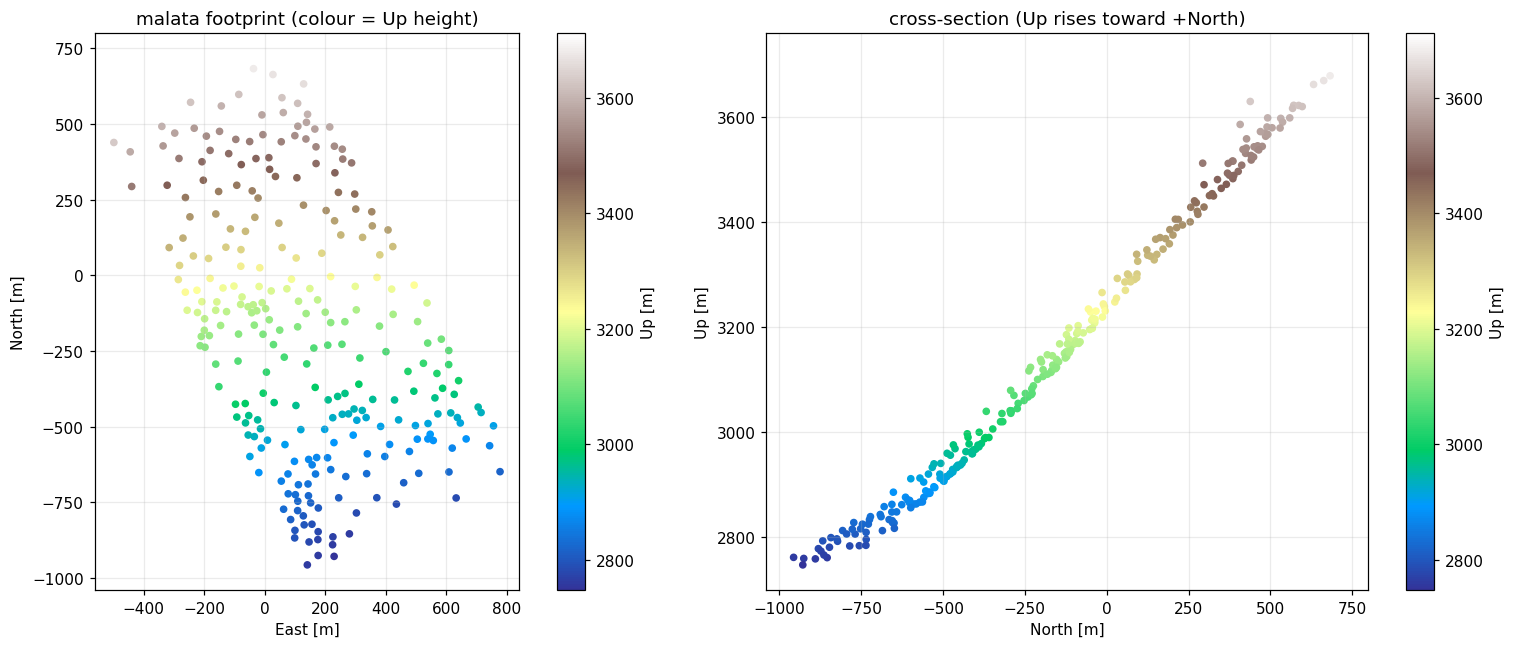

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
# Right-handed ENU map: East = x (right), North = y (up).
sc = ax[0].scatter(mE, mN, c=mU, s=16, cmap="terrain")
ax[0].set(xlabel="East [m]", ylabel="North [m]", title="malata footprint (colour = Up height)")
ax[0].set_aspect("equal"); plt.colorbar(sc, ax=ax[0], label="Up [m]")
# Cross-section: the slope rises with North (Up-North corr +0.99), so view Up vs North.
sc = ax[1].scatter(mN, mU, c=mU, s=16, cmap="terrain")
ax[1].set(xlabel="North [m]", ylabel="Up [m]", title="cross-section (Up rises toward +North)")
plt.colorbar(sc, ax=ax[1], label="Up [m]")
fig.tight_layout(); plt.show()

## 1b · The mountain in 3D

The actual triangulated detector-region surface (not just centroids), rebuilt from the mesh
vertices/faces in ENU — colour and height are `Up`. The `grid` detector layout is dropped on the
surface (black triangles). Axes are drawn to physical scale, so the ≈1 km of relief across the
≈1.7 km × 1.3 km footprint shows the real slope the showers develop over.


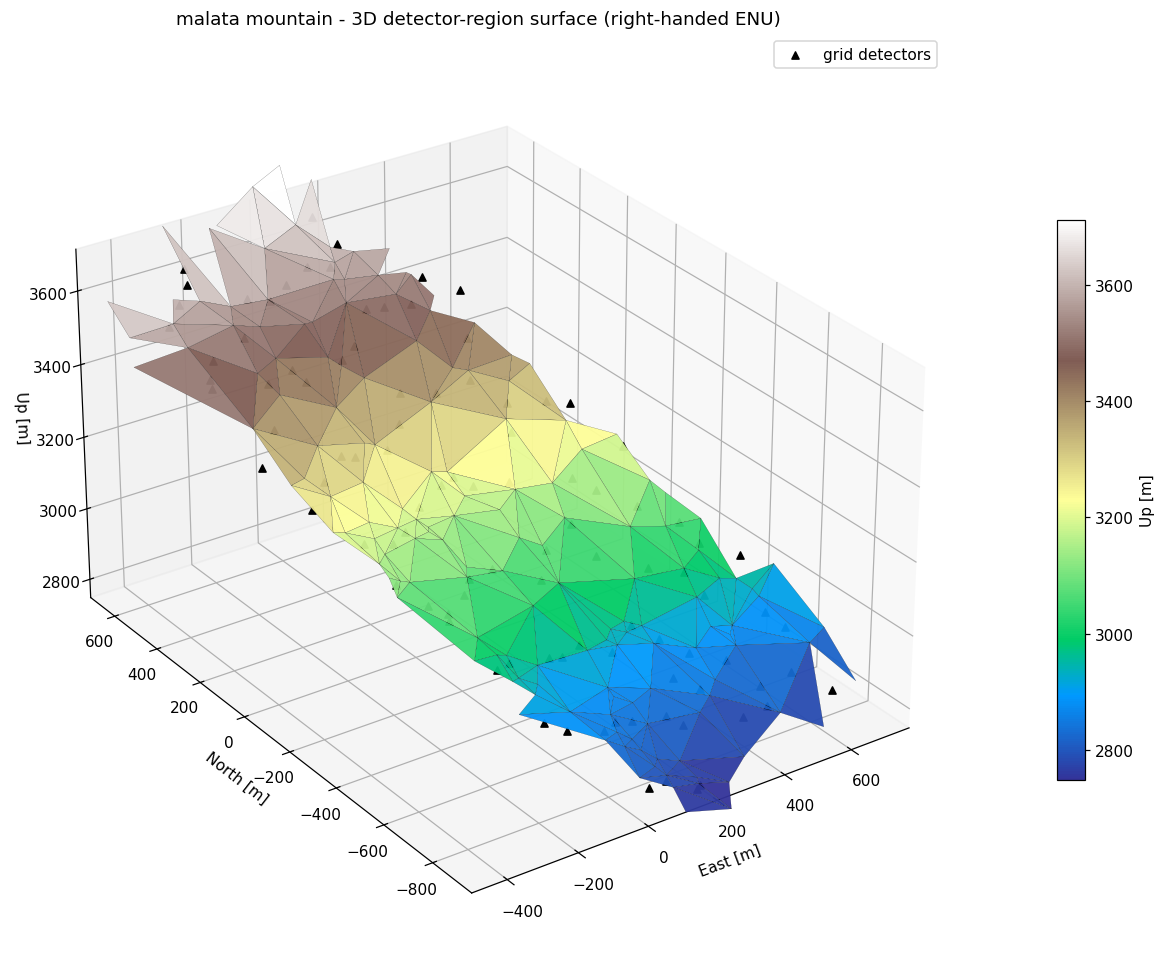

In [4]:
import matplotlib
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from modules_v4.tr_geometry import _ecef_to_enu   # ECEF->ENU, rows [East, North, Up]

# Rebuild the detector-region TRIANGLES (not centroids) in ENU about the mesh origin.
with h5py.File(GEOMETRY_PATH_RESOLVED, "r") as f:
    g = f[GEOMETRY_GROUP]
    _verts = g["vertices"][...]; _faces = g["faces"][...] - 1
    _det   = g[DET_KEY][...] - 1; _loc = g["location"][...]
_tri_ecef = _verts[:, _faces[:, _det]]
_enu = _ecef_to_enu(_tri_ecef.reshape(3, -1), float(_loc[0]), float(_loc[1]))
_E3, _N3, _U3 = (_enu[i].reshape(3, -1) for i in range(3))
# RIGHT-HANDED ENU axes: x=East, y=North, z=Up  (E x N = U).
tris   = np.stack([_E3, _N3, _U3], axis=-1).transpose(1, 0, 2)   # (Ndet, 3 vert, [E,N,Up])
tri_up = _U3.mean(axis=0)

norm = matplotlib.colors.Normalize(tri_up.min(), tri_up.max())
poly = Poly3DCollection(tris, facecolors=matplotlib.cm.terrain(norm(tri_up)),
                        edgecolors="k", linewidths=0.1, alpha=0.95)

fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection="3d")
ax.add_collection3d(poly)
Ng, Eg = layouts["grid"]            # (North, East)
ax.scatter(Eg, Ng, det_up(Ng, Eg), c="black", s=22, marker="^",
           depthshade=False, label="grid detectors")
ax.set_xlim(mE.min(), mE.max()); ax.set_ylim(mN.min(), mN.max()); ax.set_zlim(mU.min(), mU.max())
ax.set_box_aspect((np.ptp(mE), np.ptp(mN), np.ptp(mU)))   # physical scale
ax.set_xlabel("East [m]"); ax.set_ylabel("North [m]"); ax.set_zlabel("Up [m]")
ax.set_title("malata mountain - 3D detector-region surface (right-handed ENU)"); ax.legend()
ax.view_init(elev=28, azim=-125)
sm = matplotlib.cm.ScalarMappable(norm=norm, cmap="terrain"); sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.08, label="Up [m]")
fig.tight_layout(); plt.show()

## 2 · Tau decays over the mountain (`tau_wholesky.h5`)

Left: **all** 6506 surviving tau decays in the (North, East) map — they spread ±100 km; the red box is the mountain footprint. Right: a **3D view** of the mountain surface with the near-mountain decays as tiny dots — they hug the slope (100% just above the surface, median +3.7 m), the signature of Earth-skimming taus emerging from the rock and decaying in air.

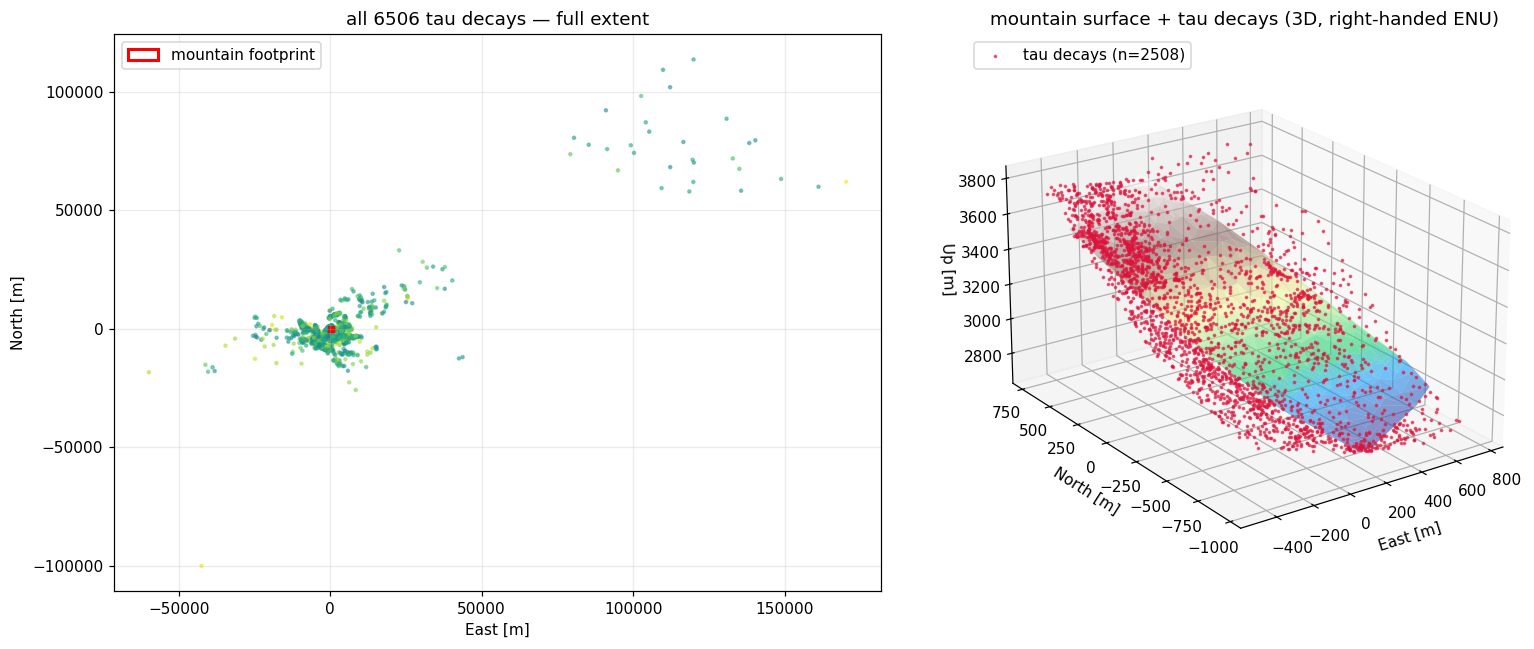

In [5]:
pad = 1500.0
sel = ((tN_n > mN.min()-pad) & (tN_n < mN.max()+pad) &
       (tE_e > mE.min()-pad) & (tE_e < mE.max()+pad))

fig = plt.figure(figsize=(15, 6))

# Left: all decays in the (East, North) map, full extent, with the footprint box.
ax0 = fig.add_subplot(1, 2, 1)
ax0.scatter(tE_e, tN_n, s=4, c=np.log10(tEne), cmap="viridis", alpha=0.5)
ax0.add_patch(Rectangle((mE.min(), mN.min()), mE.max()-mE.min(), mN.max()-mN.min(),
                        fill=False, ec="red", lw=2, label="mountain footprint"))
ax0.set(xlabel="East [m]", ylabel="North [m]",
        title=f"all {tpos.shape[1]} tau decays — full extent"); ax0.legend()

# Right: 3D mountain surface (right-handed ENU) with near-mountain decays as tiny dots.
onmtn = (tN_n > mN.min()) & (tN_n < mN.max()) & (tE_e > mE.min()) & (tE_e < mE.max())
ax1 = fig.add_subplot(1, 2, 2, projection="3d")
ax1.plot_trisurf(mE, mN, mU, cmap="terrain", alpha=0.55, linewidth=0, antialiased=True)
ax1.scatter(tE_e[onmtn], tN_n[onmtn], tU_u[onmtn], s=2, c="crimson",
            alpha=0.6, depthshade=False, label=f"tau decays (n={int(onmtn.sum())})")
ax1.set_box_aspect((np.ptp(mE), np.ptp(mN), np.ptp(mU)))
ax1.set_xlabel("East [m]"); ax1.set_ylabel("North [m]"); ax1.set_zlabel("Up [m]")
ax1.set_title("mountain surface + tau decays (3D, right-handed ENU)")
ax1.view_init(elev=22, azim=-125); ax1.legend(loc="upper left")
fig.tight_layout(); plt.show()

## 2b · Tau arrival directions (vector field)

Each near-mountain tau's **travel direction** (a UNIT vector, |d|=1) drawn as an arrow at its decay point, in the right-handed ENU frame (x=East, y=North, z=Up). Coloured by Up-component (blue = down-going, red = up-going). Mostly near-horizontal, slightly up-going (mean +0.09), with a northward lean — Earth-skimming geometry.

In [6]:
f = h5py.File(TAU_WHOLESKY_PATH, "r")
f.keys()

<KeysViewHDF5 ['direction', 'energy', 'pdg', 'position']>

In [7]:
f["direction"][:,0]

array([0.63738953, 0.61053942, 0.47008106])

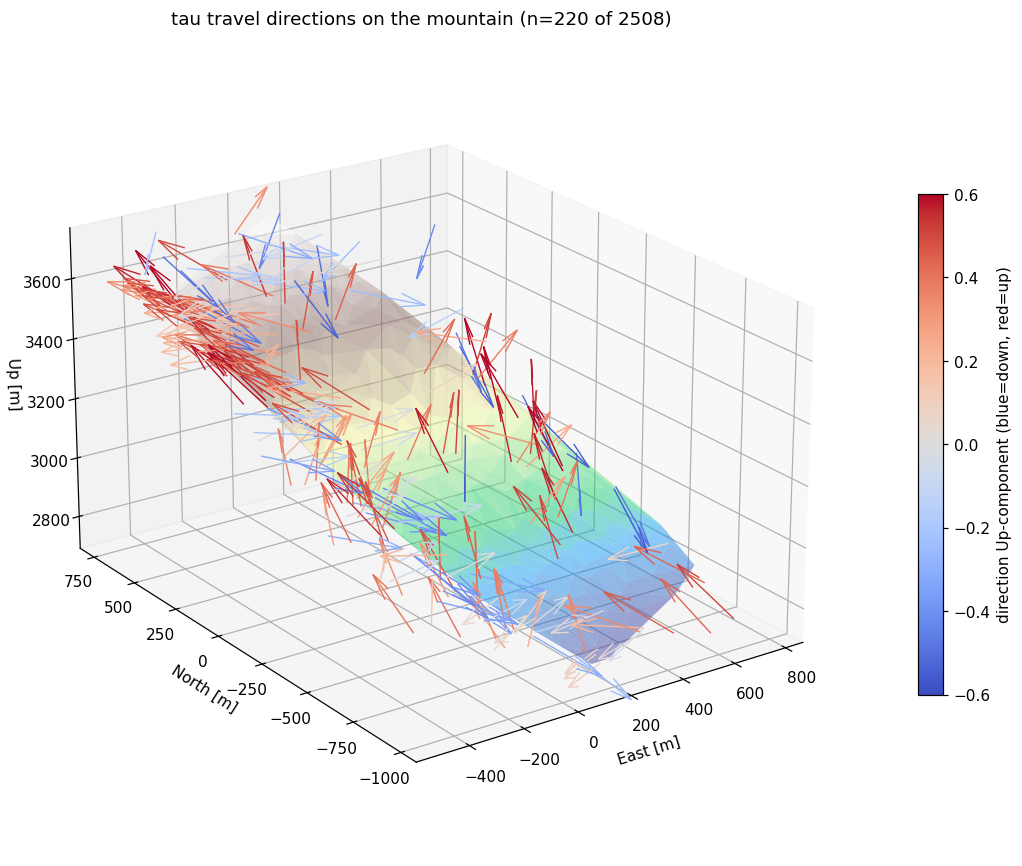

In [8]:
# Tau directions are UNIT vectors (|d| = 1.000000 exactly; ENU rows = East, North, Up).
with h5py.File(TAU_WHOLESKY_PATH, "r") as f:
    tdir = f["direction"][...]                 # (3, N)
dE, dN, dU = tdir[0], tdir[1], tdir[2]         # East, North, Up components (dimensionless cosines)

onmtn = (tN_n > mN.min()) & (tN_n < mN.max()) & (tE_e > mE.min()) & (tE_e < mE.max())
idx = np.where(onmtn)[0]
qrng = np.random.default_rng(0)
q = qrng.choice(idx, size=min(220, idx.size), replace=False)   # subsample for legibility

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(mE, mN, mU, cmap="terrain", alpha=0.45, linewidth=0, antialiased=True)

# RIGHT-HANDED axes x=East, y=North, z=Up; arrow = tau travel direction, colour = Up-component.
cmap = plt.cm.coolwarm; cn = plt.Normalize(-0.6, 0.6); cols = cmap(cn(dU[q]))
ax.quiver(tE_e[q], tN_n[q], tU_u[q], dE[q], dN[q], dU[q],
          length=250.0, normalize=True, colors=cols, linewidth=0.9, arrow_length_ratio=0.35)

ax.set_box_aspect((np.ptp(mE), np.ptp(mN), np.ptp(mU)))
ax.set_xlabel("East [m]"); ax.set_ylabel("North [m]"); ax.set_zlabel("Up [m]")
ax.set_title(f"tau travel directions on the mountain (n={q.size} of {idx.size})")
ax.view_init(elev=22, azim=-125)
sm = plt.cm.ScalarMappable(norm=cn, cmap=cmap); sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.08, label="direction Up-component (blue=down, red=up)")
fig.tight_layout(); plt.show()

## 3 · Detectors over the mountain

The `04` optimizers seed from these initial (North, East) layout strategies, each projected onto the
mountain surface. Left: four strategies in the footprint. Right: the `grid` layout lifted onto the
surface height in the (North, Up) cross-section.


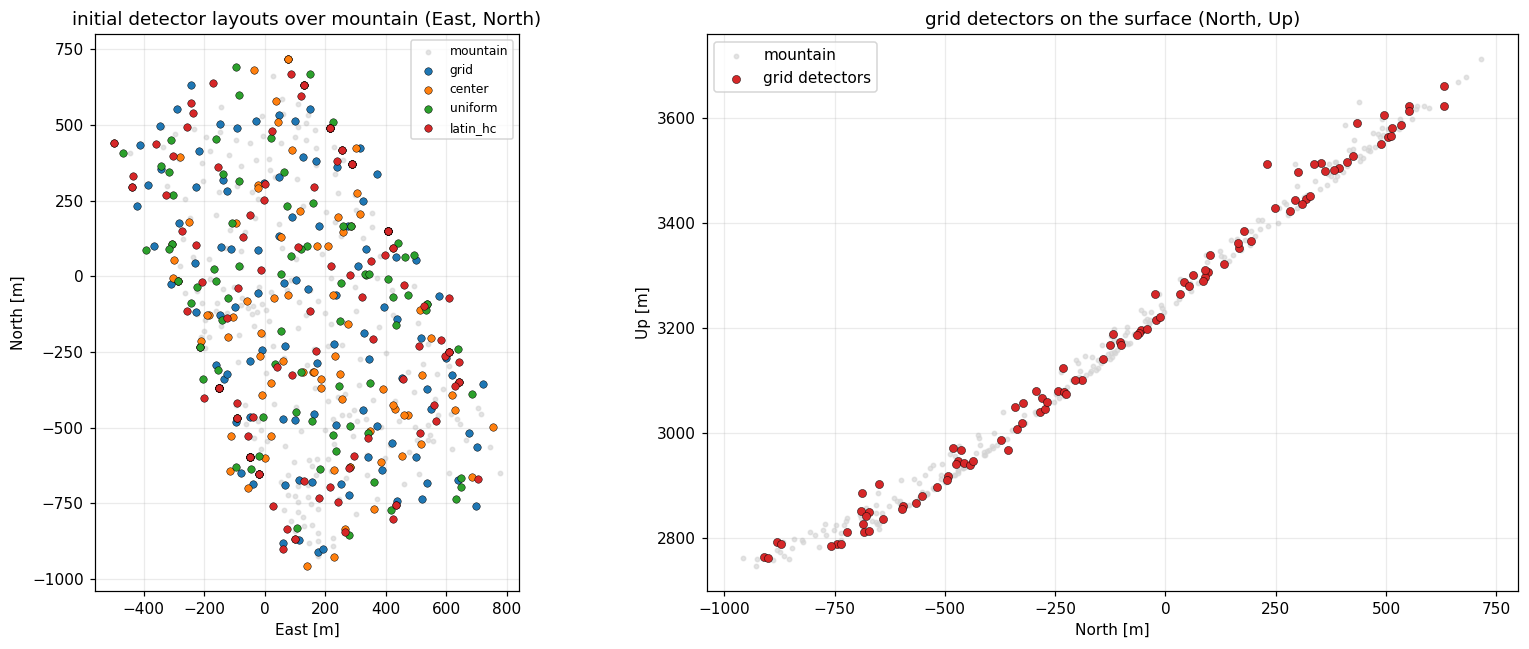

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
# Right-handed ENU map: East = x, North = y.
ax[0].scatter(mE, mN, s=8, c="lightgray", alpha=0.6, label="mountain", zorder=0)
for name, (N_, E_) in layouts.items():
    ax[0].scatter(E_, N_, s=24, edgecolors="k", linewidths=0.3, label=name, zorder=2)
ax[0].set(xlabel="East [m]", ylabel="North [m]", aspect="equal",
          title="initial detector layouts over mountain (East, North)")
ax[0].legend(loc="upper right", fontsize=8)

ax[1].scatter(mN, mU, s=8, c="lightgray", alpha=0.6, label="mountain", zorder=0)
N_, E_ = layouts["grid"]
ax[1].scatter(N_, det_up(N_, E_), s=28, c="C3", edgecolors="k", linewidths=0.3,
              label="grid detectors", zorder=2)
ax[1].set(xlabel="North [m]", ylabel="Up [m]",
          title="grid detectors on the surface (North, Up)"); ax[1].legend()
fig.tight_layout(); plt.show()

## 4 · Combined overlay

Mountain height + illuminating tau decays + a detector layout, in both projections — the geometry the
FNN surrogate and the layout optimizer actually see.


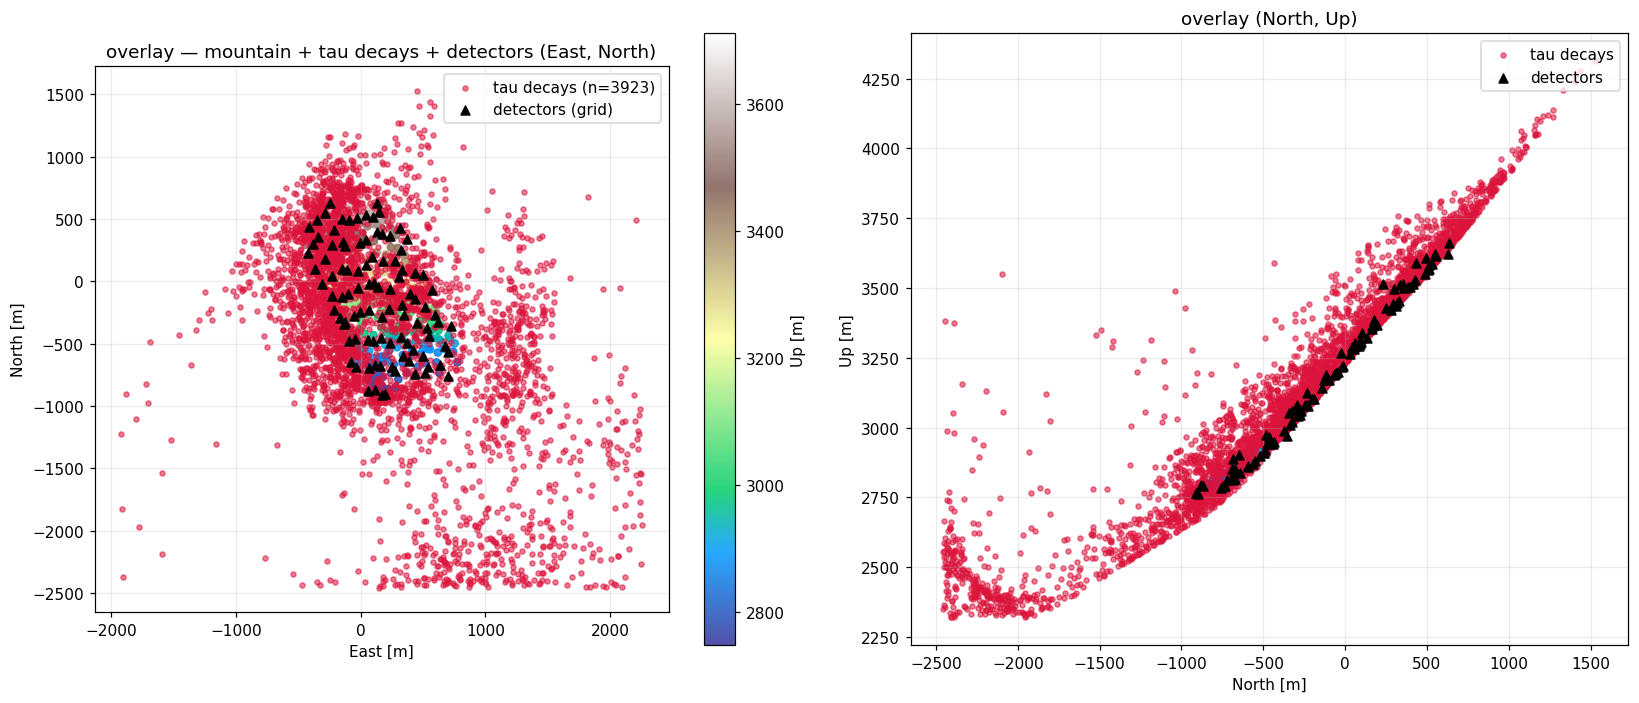

In [10]:
N_, E_ = layouts["grid"]
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))
# Right-handed ENU map: East = x, North = y.
sc = ax[0].scatter(mE, mN, c=mU, s=22, cmap="terrain", alpha=0.85, zorder=0)
ax[0].scatter(tE_e[sel], tN_n[sel], s=11, c="crimson", alpha=0.55,
              label=f"tau decays (n={int(sel.sum())})", zorder=1)
ax[0].scatter(E_, N_, s=34, c="black", marker="^", label="detectors (grid)", zorder=2)
ax[0].set(xlabel="East [m]", ylabel="North [m]", aspect="equal",
          title="overlay — mountain + tau decays + detectors (East, North)")
ax[0].legend(loc="upper right"); plt.colorbar(sc, ax=ax[0], label="Up [m]")

sc = ax[1].scatter(mN, mU, c=mU, s=22, cmap="terrain", alpha=0.75, zorder=0)
ax[1].scatter(tN_n[sel], tU_u[sel], s=11, c="crimson", alpha=0.55, label="tau decays", zorder=1)
ax[1].scatter(N_, det_up(N_, E_), s=34, c="black", marker="^", label="detectors", zorder=2)
ax[1].set(xlabel="North [m]", ylabel="Up [m]",
          title="overlay (North, Up)"); ax[1].legend(loc="upper right")
fig.tight_layout(); plt.show()

## 5 - Shower placement transformation (demo)

How one shower maps into ENU. Real point clouds come from the AllShowers generator (GPU); here an
illustrative rod is put through the **exact Step-1 transform**: its transverse (x, y) becomes
(North, Up) at the decay, and its `layer_index` becomes East depth via
`East = east_entry - layer*layer_dx`. Left: the placed shower on the mountain in 3D ENU (colour =
layer/depth). Right: the transverse (North, Up) plane the kernel matches detectors in - the rod is
compact there, its length lives entirely along East (the depth axis).

demo decay  East=115  North=-120  Up=3149


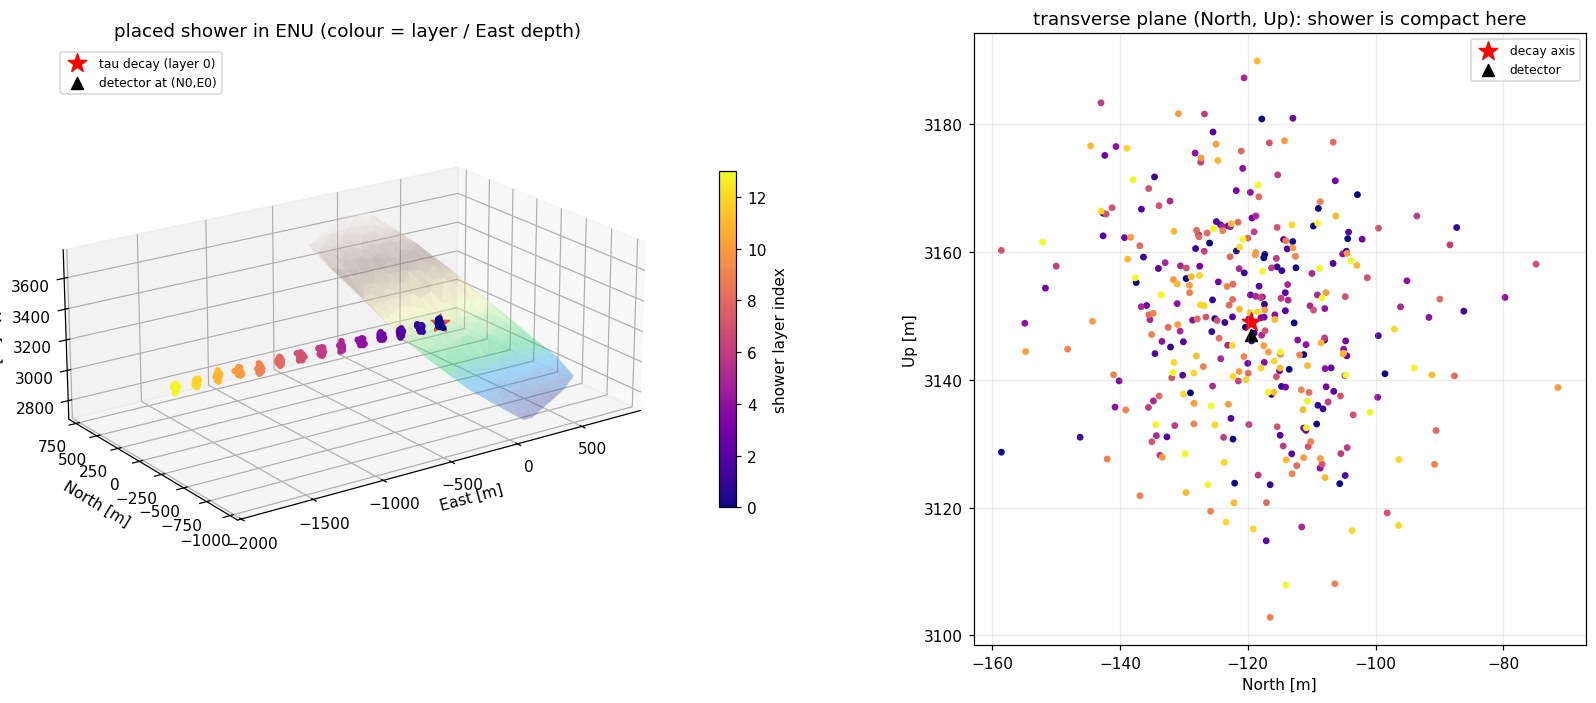

In [11]:
from modules_v6.constants import EAST_ENTRY, LAYER_EAST_DX
import torch

# Pick a real near-mountain tau decay closest to the footprint centre.
cN, cE = 0.5*(mN.min()+mN.max()), 0.5*(mE.min()+mE.max())
onm = (tN_n>mN.min())&(tN_n<mN.max())&(tE_e>mE.min())&(tE_e<mE.max())
ci = np.where(onm)[0]
j = ci[np.argmin((tN_n[ci]-cN)**2 + (tE_e[ci]-cE)**2)]
E0, N0, U0 = float(tE_e[j]), float(tN_n[j]), float(tU_u[j])
print(f"demo decay  East={E0:.0f}  North={N0:.0f}  Up={U0:.0f}")

# Illustrative rod: transverse gaussian (~15 m) x 14 longitudinal layers.
nlay, per = 14, 25
lay = np.repeat(np.arange(nlay), per).astype(np.float32)
rng = np.random.default_rng(1)
cloud = np.zeros((1, lay.size, 5), np.float32)
cloud[0,:,0] = rng.normal(0, 15, lay.size)   # transverse x
cloud[0,:,1] = rng.normal(0, 15, lay.size)   # transverse y
cloud[0,:,2] = lay                            # layer_index (depth)
cloud[0,:,3] = 1.0; cloud[0,:,4] = 1.0
c = torch.tensor(cloud)

# EXACT Step-1 placement: transverse centroid -> (N0, U0); layer shift for real East.
m = (c[:,:,3]>0).float(); w = m.sum(1).clamp(min=1)
cx = (c[:,:,0]*m).sum(1)/w; cy = (c[:,:,1]*m).sum(1)/w
c[...,0] += (N0 - cx.view(-1,1))*m                       # col0 -> North
c[...,1] += (U0 - cy.view(-1,1))*m                       # col1 -> Up
c[...,2] += (EAST_ENTRY - E0)/LAYER_EAST_DX * m          # layer -> real East depth

sN  = c[0,:,0].numpy(); sUp = c[0,:,1].numpy()
sE  = EAST_ENTRY - c[0,:,2].numpy()*LAYER_EAST_DX        # point East from layer
detUp = float(det_up(np.array([N0]), np.array([E0]))[0]) # detector height on the terrain

fig = plt.figure(figsize=(15, 6.5))

# Left: placed shower on the mountain, right-handed ENU (x=East, y=North, z=Up).
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
ax0.plot_trisurf(mE, mN, mU, cmap="terrain", alpha=0.35, linewidth=0)
p0 = ax0.scatter(sE, sN, sUp, c=lay, cmap="plasma", s=10, depthshade=False)
ax0.scatter([E0],[N0],[U0], c="red", s=160, marker="*", depthshade=False, label="tau decay (layer 0)")
ax0.scatter([E0],[N0],[detUp], c="black", s=60, marker="^", depthshade=False, label="detector at (N0,E0)")
ax0.set_box_aspect((np.ptp(np.r_[sE, mE]), np.ptp(mN), np.ptp(mU)))
ax0.set_xlabel("East [m]"); ax0.set_ylabel("North [m]"); ax0.set_zlabel("Up [m]")
ax0.set_title("placed shower in ENU (colour = layer / East depth)")
ax0.view_init(elev=20, azim=-125); ax0.legend(loc="upper left", fontsize=8)
fig.colorbar(p0, ax=ax0, shrink=0.55, pad=0.10, label="shower layer index")

# Right: the transverse (North, Up) plane - the kernel's matching plane.
ax1 = fig.add_subplot(1, 2, 2)
ax1.scatter(sN, sUp, c=lay, cmap="plasma", s=12)
ax1.scatter([N0],[U0], c="red", s=160, marker="*", label="decay axis")
ax1.scatter([N0],[detUp], c="black", s=60, marker="^", label="detector")
ax1.set(xlabel="North [m]", ylabel="Up [m]", aspect="equal",
        title="transverse plane (North, Up): shower is compact here")
ax1.legend(fontsize=8)
fig.tight_layout(); plt.show()